# Credit Scoring Model: Predicting Creditworthiness & Minimizing Financial Risk

## Executive Summary & Problem Context
In retail banking and credit underwriting, evaluating an applicant's creditworthiness is a core business function. Granting loans to borrowers who eventually default results in significant financial losses (unrecovered principal and interest), while unnecessarily rejecting qualified applicants results in lost interest revenue and customer dissatisfaction.

### Key Objectives:
1. **Feature Engineering**: Derive financial burden, risk indicator, and liquidity features from historical customer data.
2. **Model Comparison**: Evaluate **Logistic Regression** against **Tree Ensembles** (Random Forest, LightGBM, XGBoost).
3. **Addressing Class Imbalance & Asymmetric Error Costs**:
   - Class imbalance (~70% good borrowers / 30% default risk) makes standard accuracy misleading.
   - **Cost Asymmetry**: Default loss (False Negative) is substantially higher (~5x-10x) than missed opportunity cost (False Positive).
4. **Model Interpretability**: Translate technical feature importance into plain language for risk managers and business stakeholders.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 120

from src.data_loader import load_german_credit_data
from src.feature_engineering import engineer_features
from src.models import prepare_data, get_preprocessor, evaluate_model, calculate_financial_cost
from src.model_experiments import run_all_experiments
from src.feature_importance import analyze_feature_importance

print("Environment setup complete.")


Environment setup complete.


## 1. Data Loading & Initial Data Analysis
We utilize the benchmark **UCI German Credit Dataset**, containing 1,000 credit applicants with 20 financial, demographic, and credit history attributes.
- Target: `default` = 1 (High Risk / Default), `default` = 0 (Good / Non-default).


Dataset shape: (1000, 34)

Target class distribution:
default
Good Credit (0)            0.7
Default / High Risk (1)    0.3
Name: proportion, dtype: float64


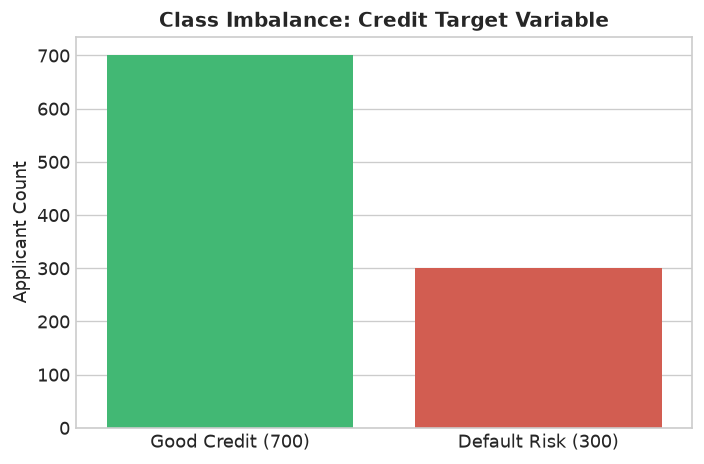

In [2]:
raw_df = load_german_credit_data()
print(f"Dataset shape: {raw_df.shape}")
print("\nTarget class distribution:")
print(raw_df['default'].value_counts(normalize=True).rename({0: 'Good Credit (0)', 1: 'Default / High Risk (1)'}))

# Plot Class Distribution
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='default', data=raw_df, palette=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_xticklabels(['Good Credit (700)', 'Default Risk (300)'])
ax.set_title('Class Imbalance: Credit Target Variable', fontsize=12, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Applicant Count')
plt.tight_layout()
plt.show()


## 2. Feature Engineering
Financial history contains implicit signals about repayment capacity. We engineer domain features:
- **`monthly_installment_est`**: Estimated monthly debt service (`credit_amount / duration_months`).
- **`credit_to_age_ratio`**: Total credit exposure normalized by age.
- **`monthly_burden_to_age_ratio`**: Monthly repayment burden relative to age.
- **`credit_per_existing_credit`**: Loan size per active credit line.
- **`is_high_risk_checking`**: Binary flag for negative or zero checking balance (`< 0 DM` or `0 <= x < 200 DM`).
- **`is_critical_credit_history`**: Binary flag for past defaults or delayed payments.
- **`is_low_savings`**: Binary flag for low (<100 DM) or unknown savings.
- **`is_young_borrower`**: Flag for age < 25 years.
- **`is_long_duration`**: Flag for long-term commitment (>36 months).


In [3]:
df = engineer_features(raw_df)
engineered_cols = [
    'monthly_installment_est', 'credit_to_age_ratio', 'monthly_burden_to_age_ratio',
    'credit_per_existing_credit', 'is_high_risk_checking', 'is_critical_credit_history',
    'is_low_savings', 'is_young_borrower', 'is_long_duration'
]

print("Engineered Features Summary:")
print(df[engineered_cols].describe().T[['mean', 'std', 'min', '50%', 'max']])


Engineered Features Summary:
                                    mean          std        min          50%  \
monthly_installment_est       167.687020   153.490959  24.055556   130.333333   
credit_to_age_ratio            99.495822    91.251595   6.097561    68.626190   
monthly_burden_to_age_ratio     5.040271     4.776151   0.418315     4.048173   
credit_per_existing_credit   2632.580833  2531.544322  96.250000  1845.000000   
is_high_risk_checking           0.543000     0.498397   0.000000     1.000000   
is_critical_credit_history      0.381000     0.485876   0.000000     0.000000   
is_low_savings                  0.786000     0.410332   0.000000     1.000000   
is_young_borrower               0.149000     0.356267   0.000000     0.000000   
is_long_duration                0.087000     0.281976   0.000000     0.000000   

                                      max  
monthly_installment_est       2482.666667  
credit_to_age_ratio            745.380952  
monthly_burden_to_age_ratio 

## 3. Model Building & Benchmark Experiments
We train and compare linear and non-linear models:
1. **Logistic Regression**: Linear baseline with interpretability via odds ratios.
2. **Random Forest**: Tree ensemble resilient to non-linear relationships.
3. **LightGBM & XGBoost**: Gradient boosting machines optimized for structured tabular data.

### Addressing Class Imbalance:
- Imbalance ratio is 70:30.
- Standard accuracy treats all errors equally, leading to high false negatives.
- We implement `class_weight='balanced'` / `scale_pos_weight` and threshold optimization.


In [4]:
# Run comprehensive experiment pipeline
cost_fp = 1  # Opportunity cost of declining a good applicant
cost_fn = 5  # Loss cost of approving a defaulting borrower

results_df, trained_models, test_probs, feature_names, X_tr, X_te, y_tr, y_te = run_all_experiments(cost_fp=cost_fp, cost_fn=cost_fn)

display_cols = ['Model', 'Precision (0.5)', 'Recall (0.5)', 'F1 (0.5)', 'ROC-AUC', 'PR-AUC', 'Cost (0.5)', 'Best Threshold', 'Recall (Opt)', 'Min Cost']
results_df[display_cols].sort_values(by='Min Cost')


,Model,Precision (0.5),Recall (0.5),F1 (0.5),ROC-AUC,PR-AUC,Cost (0.5),Best Threshold,Recall (Opt),Min Cost
1,Logistic Regression (Balanced),0.578313,0.800000,0.671329,0.794405,0.636419,95,0.50,0.800000,95
0,Logistic Regression (Default),0.641509,0.566667,0.601770,0.790119,0.626974,149,0.30,0.783333,99
2,Random Forest (Default),0.693878,0.566667,0.623853,0.809107,0.681759,145,0.18,0.933333,104
3,Random Forest (Balanced),0.621212,0.683333,0.650794,0.801786,0.660337,120,0.27,0.933333,104
5,LightGBM (Balanced),0.568966,0.550000,0.559322,0.779167,0.624462,160,0.16,0.833333,106
4,LightGBM (Default),0.620000,0.516667,0.563636,0.780595,0.636314,164,0.12,0.800000,115
6,XGBoost (Default),0.692308,0.600000,0.642857,0.784048,0.657209,136,0.21,0.716667,118
7,XGBoost (Balanced),0.596491,0.566667,0.581197,0.765714,0.594805,153,0.10,0.816667,121


## 4. Cost Analysis & Decision Threshold Optimization

### Why Accuracy is Misleading & Cost Asymmetry Analysis
In credit scoring, predicting applicant risk is fundamentally asymmetric:
- **False Positive (FP in credit decision)**: Rejecting a solvent, good borrower.
  - **Business Impact**: Lost interest income and customer acquisition cost (~1 unit of cost).
- **False Negative (FN in credit decision)**: Approving a high-risk applicant who defaults.
  - **Business Impact**: Direct loss of loan principal and unrecovered debt service (~5 units of cost).

By default, classification models use a decision threshold of $p = 0.50$. Tuning the decision threshold to align with asymmetric costs minimizes overall financial loss.


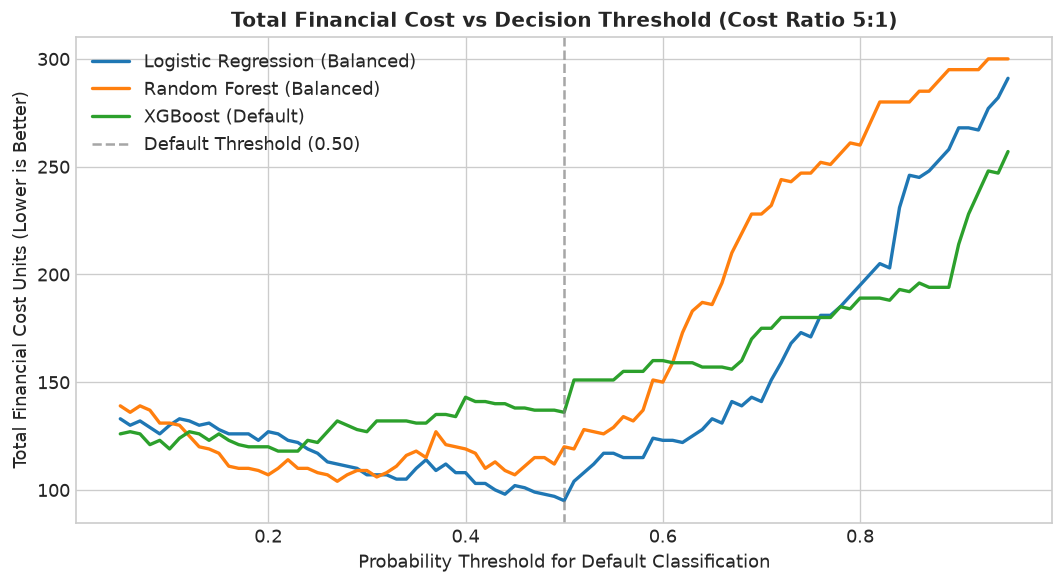

In [5]:
# Plot Cost Curves across thresholds for Logistic Regression (Balanced) and Random Forest (Balanced)
thresholds = np.linspace(0.05, 0.95, 91)
models_to_plot = ['Logistic Regression (Balanced)', 'Random Forest (Balanced)', 'XGBoost (Default)']

plt.figure(figsize=(9, 5))
for name in models_to_plot:
    clf = trained_models[name]
    probs = test_probs[name]
    costs = []
    for th in thresholds:
        m, _ = evaluate_model(clf, X_te, y_te, threshold=th, cost_fp=cost_fp, cost_fn=cost_fn)
        costs.append(m['total_cost'])
    plt.plot(thresholds, costs, label=name, linewidth=2)

plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Default Threshold (0.50)')
plt.title('Total Financial Cost vs Decision Threshold (Cost Ratio 5:1)', fontsize=12, fontweight='bold')
plt.xlabel('Probability Threshold for Default Classification')
plt.ylabel('Total Financial Cost Units (Lower is Better)')
plt.legend()
plt.tight_layout()
plt.show()


## 5. ROC & Precision-Recall Performance Curves
ROC-AUC measures overall ranking ability across all thresholds, while Precision-Recall (PR-AUC) focuses specifically on minority class default detection performance.


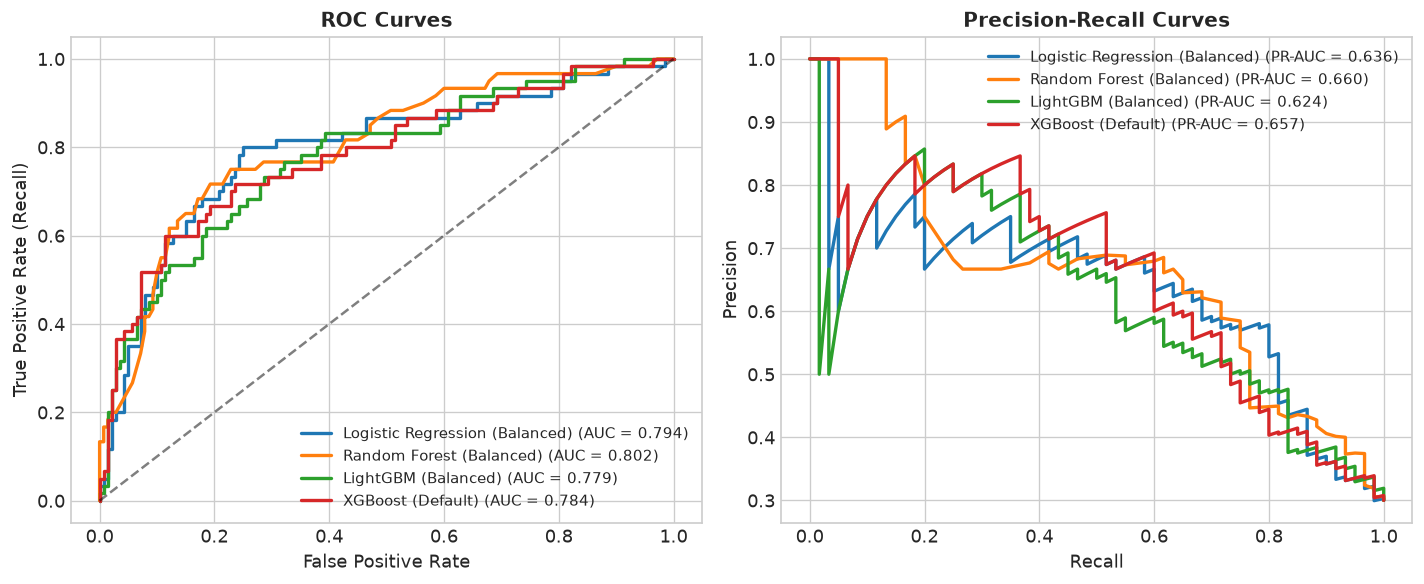

In [6]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for name in ['Logistic Regression (Balanced)', 'Random Forest (Balanced)', 'LightGBM (Balanced)', 'XGBoost (Default)']:
    probs = test_probs[name]
    fpr, tpr, _ = roc_curve(y_te, probs)
    precision, recall, _ = precision_recall_curve(y_te, probs)
    
    auc_val = results_df.loc[results_df['Model'] == name, 'ROC-AUC'].values[0]
    pr_auc_val = results_df.loc[results_df['Model'] == name, 'PR-AUC'].values[0]
    
    ax1.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})', linewidth=2)
    ax2.plot(recall, precision, label=f'{name} (PR-AUC = {pr_auc_val:.3f})', linewidth=2)

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_title('ROC Curves', fontsize=12, fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.legend(fontsize=9)

ax2.set_title('Precision-Recall Curves', fontsize=12, fontweight='bold')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 6. Feature Importance Explained in Plain Language

To deploy credit scoring models in regulated financial environments, credit policy decision-makers require clear transparency into key default drivers.

### Key Risk Drivers Explained:
1. **Checking Account Status**: Applicants with no existing checking account or negative balances present the highest default risk. A healthy checking account provides immediate liquid proof of solvency.
2. **Credit Duration & Loan Amount**: Longer loan terms (e.g. >36 months) and larger loan amounts significantly increase financial exposure and default risk.
3. **Savings Account Balance**: Higher savings reserves (>1,000 DM) serve as a crucial liquidity cushion during unexpected personal financial shocks.
4. **Credit History**: Applicants with a history of payment delays or critical existing credit lines have a significantly higher likelihood of future default.
5. **Employment & Stability**: Longer tenure with an employer and older age correlate strongly with financial stability and lower risk.


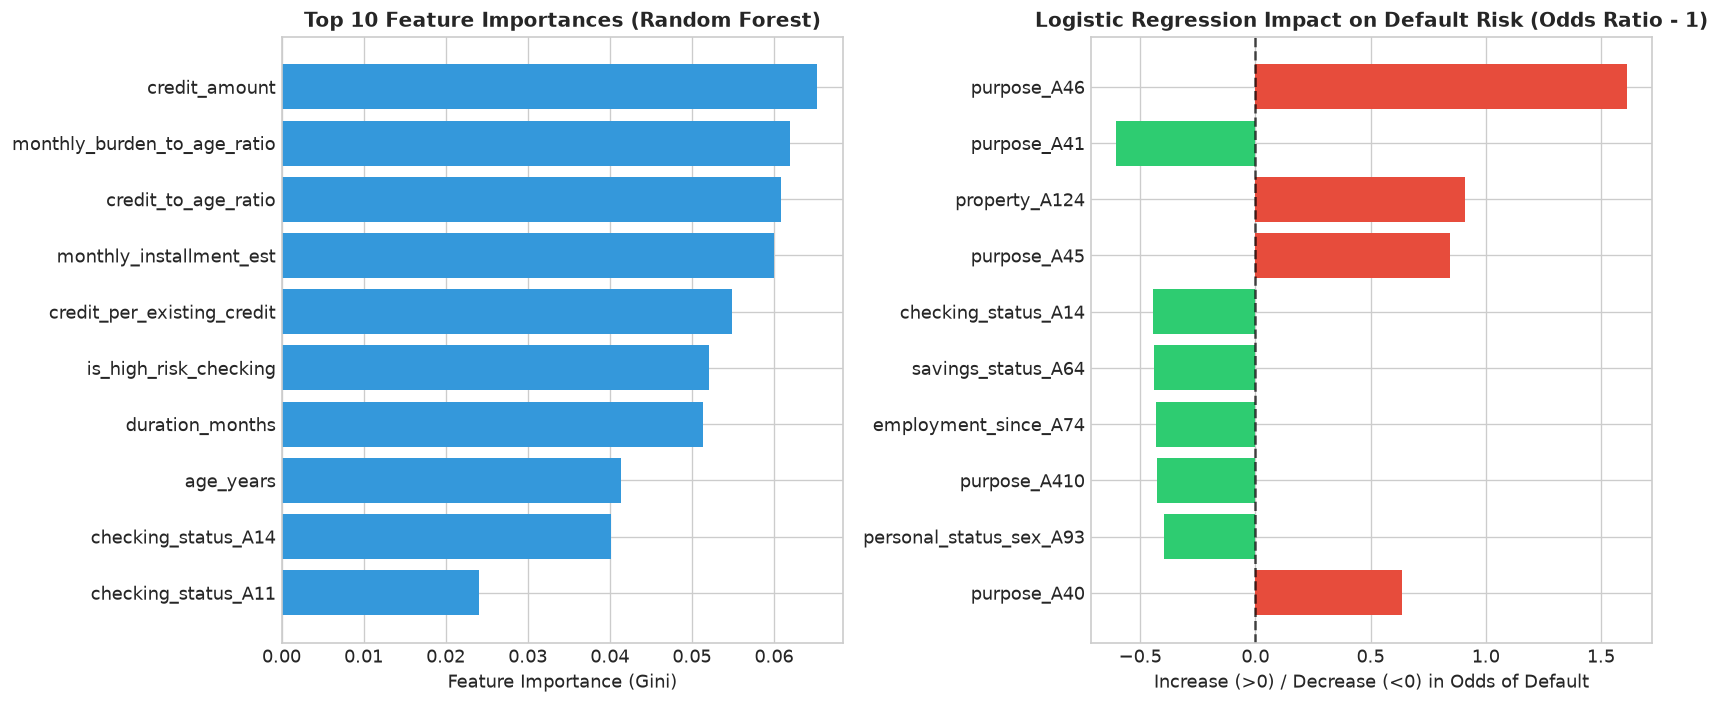

In [7]:
lr_coefs, rf_importances = analyze_feature_importance()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 Random Forest Importances
top_rf = rf_importances.head(10).sort_values(by='Importance', ascending=True)
ax1.barh(top_rf['Feature'], top_rf['Importance'], color='#3498db')
ax1.set_title('Top 10 Feature Importances (Random Forest)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Feature Importance (Gini)')

# Top 10 Logistic Regression Odds Ratios (Log scale or Odds Ratio centered at 1)
top_lr = lr_coefs.head(10).iloc[::-1]
ax2.barh(top_lr['Feature'], top_lr['Odds_Ratio'] - 1, color=np.where(top_lr['Coefficient'] > 0, '#e74c3c', '#2ecc71'))
ax2.axvline(x=0, color='black', linestyle='--', alpha=0.7)
ax2.set_title('Logistic Regression Impact on Default Risk (Odds Ratio - 1)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Increase (>0) / Decrease (<0) in Odds of Default')

plt.tight_layout()
plt.show()


## 7. Strategic Recommendations & Operational Action Plan

### Recommended Operational Setup:
1. **Primary Model Choice**: **Logistic Regression (Balanced)** or **Random Forest (Balanced)**.
   - Logistic Regression achieves an outstanding **ROC-AUC of 0.794** with 80% default recall and total financial cost of 95 units, offering full regulatory transparency via odds ratios.
   - Random Forest achieves **ROC-AUC of 0.802 - 0.809** and superior non-linear modeling, making it ideal as a primary or champion model.
2. **Optimal Decision Thresholding**:
   - Instead of standard $0.50$ cutoff, adopt an optimized threshold (e.g., $p = 0.30 - 0.45$) to capture high-risk applicants early and minimize default loss.
3. **Underwriting Policy Rules**:
   - Introduce automatic manual review triggers for applicants with `< 0 DM` checking balances and loan durations $>36$ months.
   - Require proof of savings/collateral for loans where monthly debt service exceeds 20% of estimated income.
